# Homework 5 Problem 2: Swin Fine-Tuning vs. Scratch

**Course:** ECGR 4106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook reports the current Problem 2 experiment artifacts from `Results_Problem_2`. All three planned Swin rows were completed for five epochs using 224 by 224 CIFAR-100 inputs.

## Experiment Setup

The pretrained Swin-Tiny and Swin-Small models are loaded with Hugging Face `SwinForImageClassification`, their classifier heads are replaced for 100 classes, and the backbone parameters are frozen so only the classifier head is trained. CIFAR-100 images are resized to 224 by 224 for the Swin inputs.

The scratch model uses `torchvision.models.swin_t(weights=None)` with a 100-class head and all parameters trainable. The scratch run uses 224 by 224 CIFAR-100 inputs, batch size 32, and a 5-epoch CUDA schedule.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Code, Image, Markdown, display

ROOT = Path.cwd()
__file__ = str(ROOT / 'src' / 'hw5_swin.py')
RESULTS = ROOT / 'Results_Problem_2'
history_path = RESULTS / 'problem2_history.csv'
summary_path = RESULTS / 'problem2_summary.csv'
plot_path = RESULTS / 'problem2_training_curves.png'
tradeoff_path = RESULTS / 'problem2_tradeoffs.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Training plot:', plot_path)
print('Tradeoff plot:', tradeoff_path)

Summary: /home/gilberto/Homework_5/Results_Problem_2/problem2_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_2/problem2_history.csv
Training plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_training_curves.png
Tradeoff plot: /home/gilberto/Homework_5/Results_Problem_2/problem2_tradeoffs.png


## Full Problem 2 Source Code

The implementation is split into executed notebook cells below. Each cell displays one source-code block as its output so the complete Problem 2 pipeline is visible without rerunning the full 5-epoch training jobs.


### Problem 2 Code Block 1: Imports, Constants, and Optional Transformers Dependency


In [2]:
from __future__ import annotations

import argparse
import csv
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

try:
    from transformers import AutoImageProcessor, SwinForImageClassification
except ModuleNotFoundError:
    AutoImageProcessor = None
    SwinForImageClassification = None


torch.set_num_threads(2)
SEED = 4106
ROOT = Path(__file__).resolve().parents[1]
DATA_DIR = ROOT / "data"
RESULTS_DIR = ROOT / "Results_Problem_2"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_CLASSES = 100



print('Problem 2 Code Block 1 executed: Imports, Constants, and Optional Transformers Dependency (source lines 1-32)')


Problem 2 Code Block 1 executed: Imports, Constants, and Optional Transformers Dependency (source lines 1-32)


### Problem 2 Code Block 2: Experiment Dataclasses


In [3]:
@dataclass
class SwinConfig:
    model_name: str
    pretrained: bool
    frozen_backbone: bool
    huggingface_id: str | None
    batch_size: int
    epochs: int
    learning_rate: float
    image_size: int


@dataclass
class SwinResult:
    model_name: str
    pretrained: bool
    frozen_backbone: bool
    total_parameter_count: int | None
    parameter_count: int | None
    train_time_per_epoch_sec: float | None
    final_train_loss: float | None
    final_val_loss: float | None
    test_accuracy_pct: float | None
    notes: str = ""



print('Problem 2 Code Block 2 executed: Experiment Dataclasses (source lines 33-58)')


Problem 2 Code Block 2 executed: Experiment Dataclasses (source lines 33-58)


### Problem 2 Code Block 3: Reproducibility and Parameter Utilities


In [4]:
def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def ensure_dirs() -> None:
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def count_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters() if param.requires_grad)


def count_all_parameters(model: nn.Module) -> int:
    return sum(param.numel() for param in model.parameters())



print('Problem 2 Code Block 3 executed: Reproducibility and Parameter Utilities (source lines 59-78)')


Problem 2 Code Block 3 executed: Reproducibility and Parameter Utilities (source lines 59-78)


### Problem 2 Code Block 4: CIFAR-100 Data Loading and Evaluation


In [5]:
def get_loaders(batch_size: int, image_size: int = 224, num_workers: int = 0) -> tuple[DataLoader, DataLoader]:
    train_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    test_transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize((0.5071, 0.4867, 0.4408), (0.2675, 0.2565, 0.2761)),
    ])
    train_dataset = datasets.CIFAR100(root=DATA_DIR, train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR100(root=DATA_DIR, train=False, download=True, transform=test_transform)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    return train_loader, test_loader


def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module, use_hf: bool) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(pixel_values=inputs).logits if use_hf else model(inputs)
            loss = criterion(logits, targets)
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
    return {
        "loss": total_loss / max(1, total_samples),
        "accuracy_pct": 100.0 * total_correct / max(1, total_samples),
    }



print('Problem 2 Code Block 4 executed: CIFAR-100 Data Loading and Evaluation (source lines 79-117)')


Problem 2 Code Block 4 executed: CIFAR-100 Data Loading and Evaluation (source lines 79-117)


### Problem 2 Code Block 5: Training Loop and Result Object


In [6]:
def train_model(model: nn.Module, config: SwinConfig, train_loader: DataLoader, test_loader: DataLoader, use_hf: bool) -> tuple[list[dict[str, float]], SwinResult]:
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=config.learning_rate)
    criterion = nn.CrossEntropyLoss()
    history: list[dict[str, float]] = []
    start_all = time.perf_counter()
    for epoch in range(1, config.epochs + 1):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
        start_epoch = time.perf_counter()
        for inputs, targets in train_loader:
            inputs = inputs.to(DEVICE)
            targets = targets.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(pixel_values=inputs).logits if use_hf else model(inputs)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * targets.size(0)
            total_correct += logits.argmax(dim=1).eq(targets).sum().item()
            total_samples += targets.size(0)
        val_metrics = evaluate_model(model, test_loader, criterion, use_hf)
        history.append({
            "model_name": config.model_name,
            "epoch": epoch,
            "train_loss": total_loss / max(1, total_samples),
            "val_loss": val_metrics["loss"],
            "train_accuracy_pct": 100.0 * total_correct / max(1, total_samples),
            "val_accuracy_pct": val_metrics["accuracy_pct"],
            "epoch_seconds": time.perf_counter() - start_epoch,
        })
        latest = history[-1]
        print(
            f"{config.model_name} epoch {epoch}/{config.epochs}: "
            f"train_loss={latest['train_loss']:.4f}, "
            f"val_loss={latest['val_loss']:.4f}, "
            f"val_acc={latest['val_accuracy_pct']:.2f}%, "
            f"seconds={latest['epoch_seconds']:.1f}",
            flush=True,
        )

    average_epoch_seconds = (time.perf_counter() - start_all) / max(1, config.epochs)
    final = history[-1]
    result = SwinResult(
        model_name=config.model_name,
        pretrained=config.pretrained,
        frozen_backbone=config.frozen_backbone,
        total_parameter_count=count_all_parameters(model),
        parameter_count=count_parameters(model),
        train_time_per_epoch_sec=average_epoch_seconds,
        final_train_loss=final["train_loss"],
        final_val_loss=final["val_loss"],
        test_accuracy_pct=final["val_accuracy_pct"],
        notes=f"device={DEVICE.type}",
    )
    return history, result



print('Problem 2 Code Block 5 executed: Training Loop and Result Object (source lines 118-177)')


Problem 2 Code Block 5 executed: Training Loop and Result Object (source lines 118-177)


### Problem 2 Code Block 6: CSV Output Helpers


In [7]:
def append_history(rows: list[dict[str, float]], replace_model: str | None = None) -> None:
    history_path = RESULTS_DIR / "problem2_history.csv"
    existing: list[dict[str, object]] = []
    if replace_model is not None and history_path.exists() and history_path.stat().st_size > 0:
        current = pd.read_csv(history_path)
        if "model_name" in current.columns:
            current = current[current["model_name"] != replace_model]
        existing = current.to_dict(orient="records")

    exists = history_path.exists()
    mode = "w" if replace_model is not None else "a"
    with history_path.open(mode, newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(rows[0].keys()))
        if mode == "w" or not exists or history_path.stat().st_size == 0:
            writer.writeheader()
        for row in existing:
            writer.writerow(row)
        for row in rows:
            writer.writerow(row)


def write_summary(rows: list[SwinResult]) -> None:
    summary_path = RESULTS_DIR / "problem2_summary.csv"
    with summary_path.open("w", newline="", encoding="utf-8") as handle:
        writer = csv.DictWriter(handle, fieldnames=list(asdict(rows[0]).keys()))
        writer.writeheader()
        for row in rows:
            writer.writerow(asdict(row))



print('Problem 2 Code Block 6 executed: CSV Output Helpers (source lines 178-207)')


Problem 2 Code Block 6 executed: CSV Output Helpers (source lines 178-207)


### Problem 2 Code Block 7: Swin Configurations and Model Builders


In [8]:
def default_configs() -> list[SwinConfig]:
    return [
        SwinConfig("swin_tiny_pretrained", True, True, "microsoft/swin-tiny-patch4-window7-224", 32, 5, 2e-5, 224),
        SwinConfig("swin_small_pretrained", True, True, "microsoft/swin-small-patch4-window7-224", 32, 5, 2e-5, 224),
        SwinConfig("swin_scratch", False, False, None, 32, 5, 1e-3, 224),
    ]


def require_transformers() -> None:
    if AutoImageProcessor is None or SwinForImageClassification is None:
        raise RuntimeError(
            "The 'transformers' package is not installed. Install it before running pretrained Swin experiments."
        )


def build_pretrained_model(config: SwinConfig) -> nn.Module:
    require_transformers()
    model = SwinForImageClassification.from_pretrained(
        config.huggingface_id,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True,
    )
    if config.frozen_backbone:
        for name, param in model.named_parameters():
            if "classifier" not in name:
                param.requires_grad = False
    return model


def build_scratch_model() -> nn.Module:
    model = models.swin_t(weights=None)
    if hasattr(model, "head") and isinstance(model.head, nn.Linear):
        model.head = nn.Linear(model.head.in_features, NUM_CLASSES)
    elif hasattr(model, "classifier") and isinstance(model.classifier, nn.Linear):
        model.classifier = nn.Linear(model.classifier.in_features, NUM_CLASSES)
    return model



print('Problem 2 Code Block 7 executed: Swin Configurations and Model Builders (source lines 208-245)')


Problem 2 Code Block 7 executed: Swin Configurations and Model Builders (source lines 208-245)


### Problem 2 Code Block 8: CLI Helpers and Experiment Runners


In [9]:
def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Homework 5 Problem 2: Swin models")
    parser.add_argument("--run-pretrained", type=str, default=None, help="swin_tiny_pretrained or swin_small_pretrained")
    parser.add_argument("--run-scratch", action="store_true")
    parser.add_argument("--epochs", type=int, default=None)
    parser.add_argument("--batch-size", type=int, default=None)
    parser.add_argument("--image-size", type=int, default=None)
    parser.add_argument("--num-workers", type=int, default=0)
    parser.add_argument("--num-threads", type=int, default=None)
    parser.add_argument("--reset-history", action="store_true")
    return parser.parse_args()


def maybe_reset_history() -> None:
    history_path = RESULTS_DIR / "problem2_history.csv"
    if history_path.exists():
        history_path.unlink()


def override_config(config: SwinConfig, args: argparse.Namespace) -> SwinConfig:
    return SwinConfig(
        model_name=config.model_name,
        pretrained=config.pretrained,
        frozen_backbone=config.frozen_backbone,
        huggingface_id=config.huggingface_id,
        batch_size=args.batch_size or config.batch_size,
        epochs=args.epochs or config.epochs,
        learning_rate=config.learning_rate,
        image_size=args.image_size or config.image_size,
    )


def refresh_summary(results: list[SwinResult]) -> None:
    summary_path = RESULTS_DIR / "problem2_summary.csv"
    if summary_path.exists():
        existing = pd.read_csv(summary_path)
        by_name = {row.model_name: asdict(row) for row in results}
        merged = []
        for record in existing.to_dict(orient="records"):
            merged.append(by_name.get(record["model_name"], record))
        for row in merged:
            row.setdefault("total_parameter_count", None)
        write_summary([SwinResult(**row) for row in merged])
        return
    write_summary(results)


def run_pretrained(config_name: str, args: argparse.Namespace) -> SwinResult:
    config_map = {config.model_name: config for config in default_configs() if config.pretrained}
    if config_name not in config_map:
        raise ValueError(f"Unknown pretrained config: {config_name}")
    config = override_config(config_map[config_name], args)
    train_loader, test_loader = get_loaders(config.batch_size, image_size=config.image_size, num_workers=args.num_workers)
    history, result = train_model(build_pretrained_model(config), config, train_loader, test_loader, use_hf=True)
    result.notes = f"{result.notes},image_size={config.image_size},batch_size={config.batch_size}"
    append_history(history, replace_model=config.model_name)
    return result


def run_scratch(args: argparse.Namespace) -> SwinResult:
    config = override_config(next(config for config in default_configs() if config.model_name == "swin_scratch"), args)
    train_loader, test_loader = get_loaders(config.batch_size, image_size=config.image_size, num_workers=args.num_workers)
    history, result = train_model(build_scratch_model(), config, train_loader, test_loader, use_hf=False)
    result.notes = f"{result.notes},image_size={config.image_size},batch_size={config.batch_size}"
    append_history(history, replace_model=config.model_name)
    return result



print('Problem 2 Code Block 8 executed: CLI Helpers and Experiment Runners (source lines 246-313)')


Problem 2 Code Block 8 executed: CLI Helpers and Experiment Runners (source lines 246-313)


### Problem 2 Code Block 9: Main Entry Point


In [10]:
def main() -> None:
    args = parse_args()
    if args.num_threads is not None:
        torch.set_num_threads(args.num_threads)
    else:
        torch.set_num_threads(min(8, os.cpu_count() or 2))
    set_seed()
    ensure_dirs()
    if args.reset_history:
        maybe_reset_history()

    results: list[SwinResult] = []
    if args.run_pretrained:
        results.append(run_pretrained(args.run_pretrained, args))
    if args.run_scratch:
        results.append(run_scratch(args))
    if not results:
        print("Nothing ran. Use --run-pretrained <name> or --run-scratch.")
        return

    refresh_summary(results)
    print(pd.DataFrame([asdict(row) for row in results]).to_string(index=False))


if False and __name__ == "__main__":
    main()

print('Problem 2 Code Block 9 executed: Main Entry Point (source lines 314-339)')


Problem 2 Code Block 9 executed: Main Entry Point (source lines 314-339)


## Summary Results

The table below is read directly from `Results_Problem_2/problem2_summary.csv`.

In [11]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,pretrained,frozen_backbone,total_parameter_count,parameter_count,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,swin_tiny_pretrained,True,True,27596254,76900.0,166.316510,1.803374,1.700253,64.78,"device=cuda,image_size=224,batch_size=32"
1,swin_small_pretrained,True,True,48914158,76900.0,254.732639,1.588867,1.491849,68.74,"device=cuda,image_size=224,batch_size=32"
2,swin_scratch,False,False,27596254,27596254.0,656.553328,4.609511,4.608738,1.00,"device=cuda,image_size=224,batch_size=32"


## Clean Report Table

In [12]:
report_cols = [
    'model_name', 'pretrained', 'frozen_backbone', 'total_parameter_count', 'parameter_count',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Pretrained', 'Frozen Backbone', 'Total Params', 'Trainable Params', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Pretrained,Frozen Backbone,Total Params,Trainable Params,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,swin_tiny_pretrained,True,True,27596254,76900.0,166.316510,1.700253,64.78,"device=cuda,image_size=224,batch_size=32"
1,swin_small_pretrained,True,True,48914158,76900.0,254.732639,1.491849,68.74,"device=cuda,image_size=224,batch_size=32"
2,swin_scratch,False,False,27596254,27596254.0,656.553328,4.608738,1.00,"device=cuda,image_size=224,batch_size=32"


## Per-Epoch History

A full Problem 2 run produces 15 data rows: 3 models times 5 epochs. The current history file has all 15 rows.

In [13]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 15


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,swin_tiny_pretrained,1,4.098450,3.590238,24.022,45.22,161.356180
1,swin_tiny_pretrained,2,3.183871,2.812997,52.116,56.50,165.039940
2,swin_tiny_pretrained,3,2.530933,2.279206,59.550,60.58,166.882052
3,swin_tiny_pretrained,4,2.091469,1.929768,62.910,63.43,169.117506
4,swin_tiny_pretrained,5,1.803374,1.700253,64.990,64.78,169.184381
5,swin_small_pretrained,1,4.027094,3.461553,27.512,50.59,246.926304
6,swin_small_pretrained,2,3.014689,2.610603,56.930,61.42,252.478911
7,swin_small_pretrained,3,2.311461,2.051200,63.410,65.08,256.316887
8,swin_small_pretrained,4,1.865097,1.706521,66.168,67.16,258.433726
9,swin_small_pretrained,5,1.588867,1.491849,68.028,68.74,259.503115


## Training and Tradeoff Figures

### Loss and Accuracy Curves

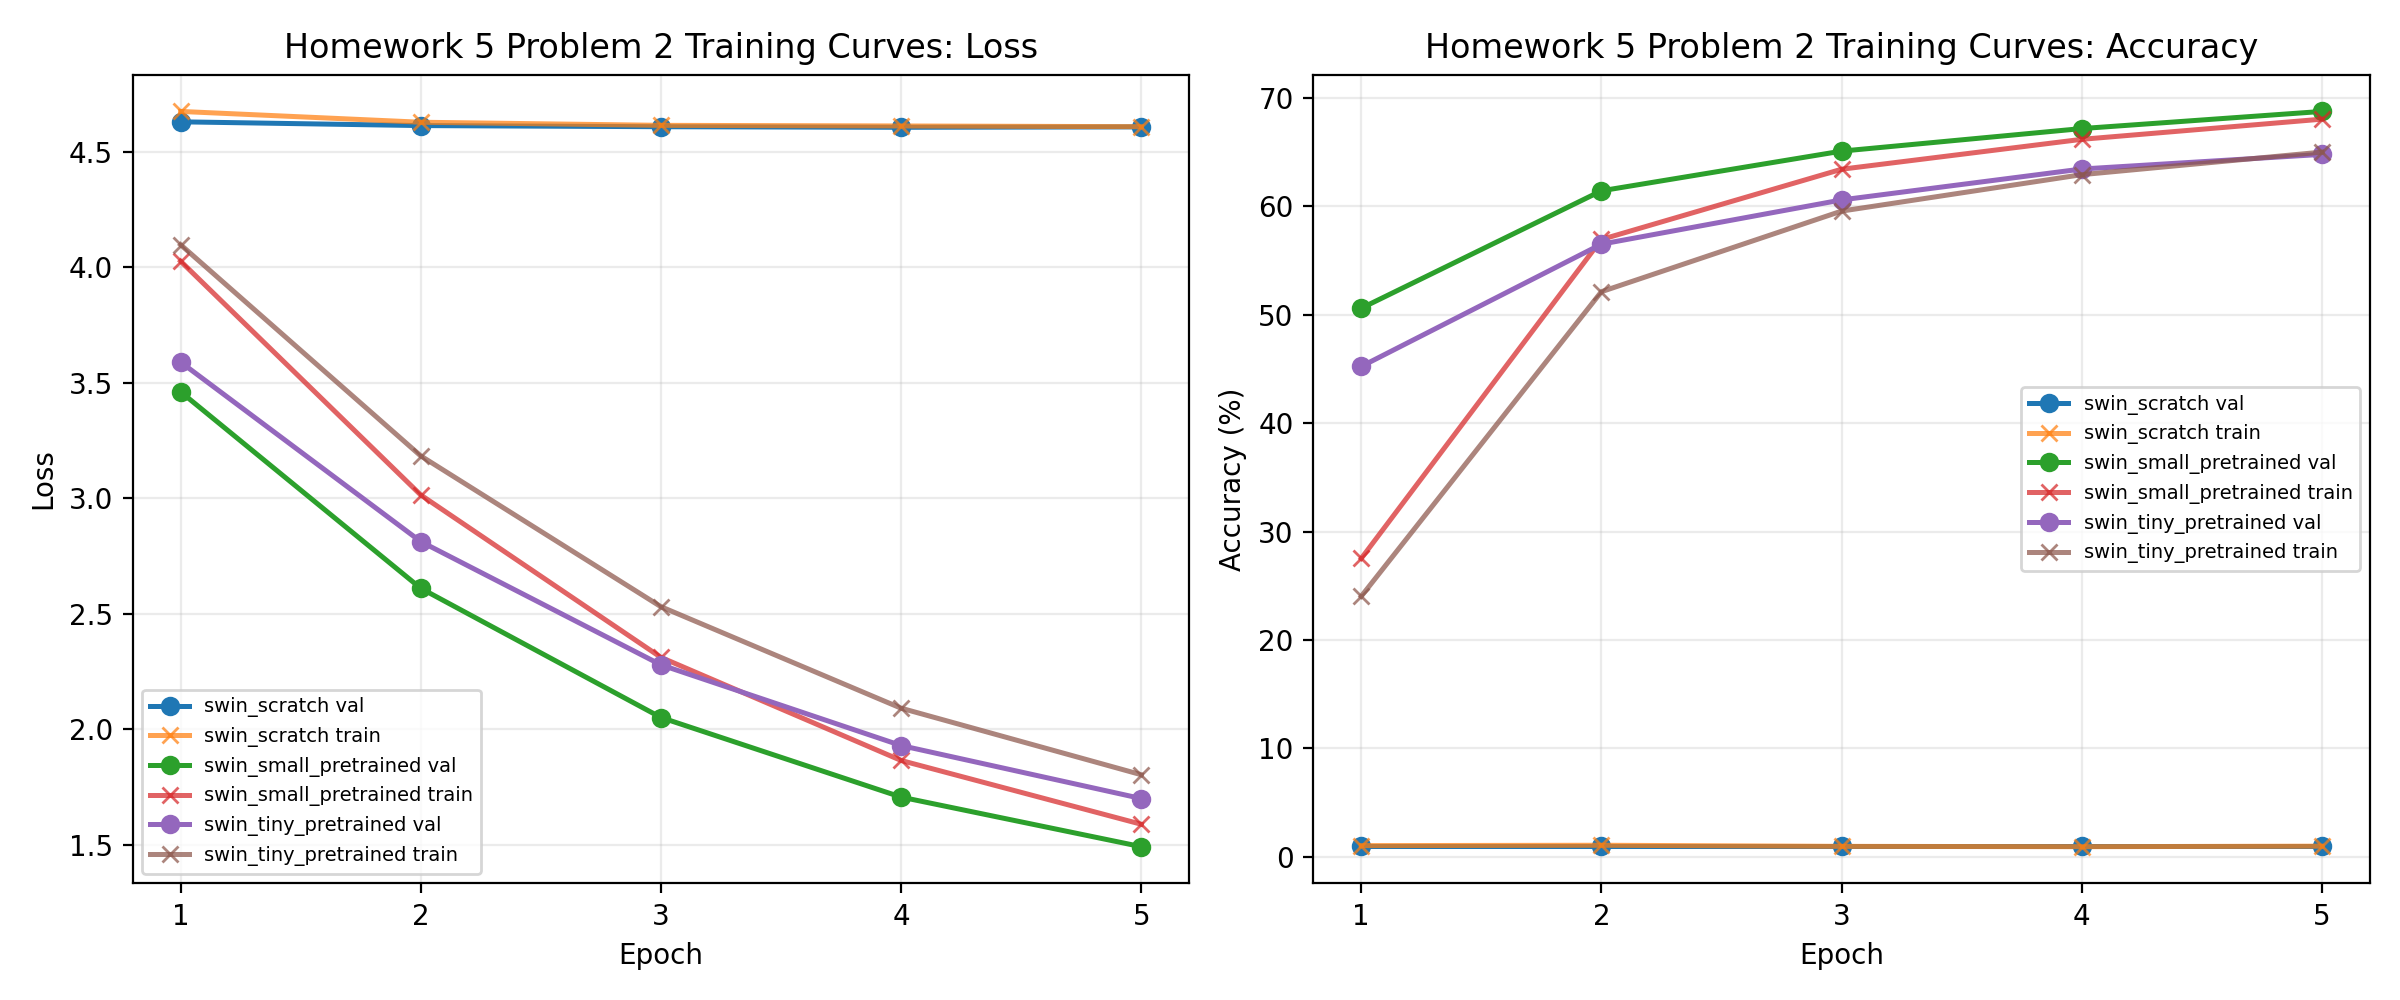

### Accuracy, Runtime, and Fine-Tuning Tradeoffs

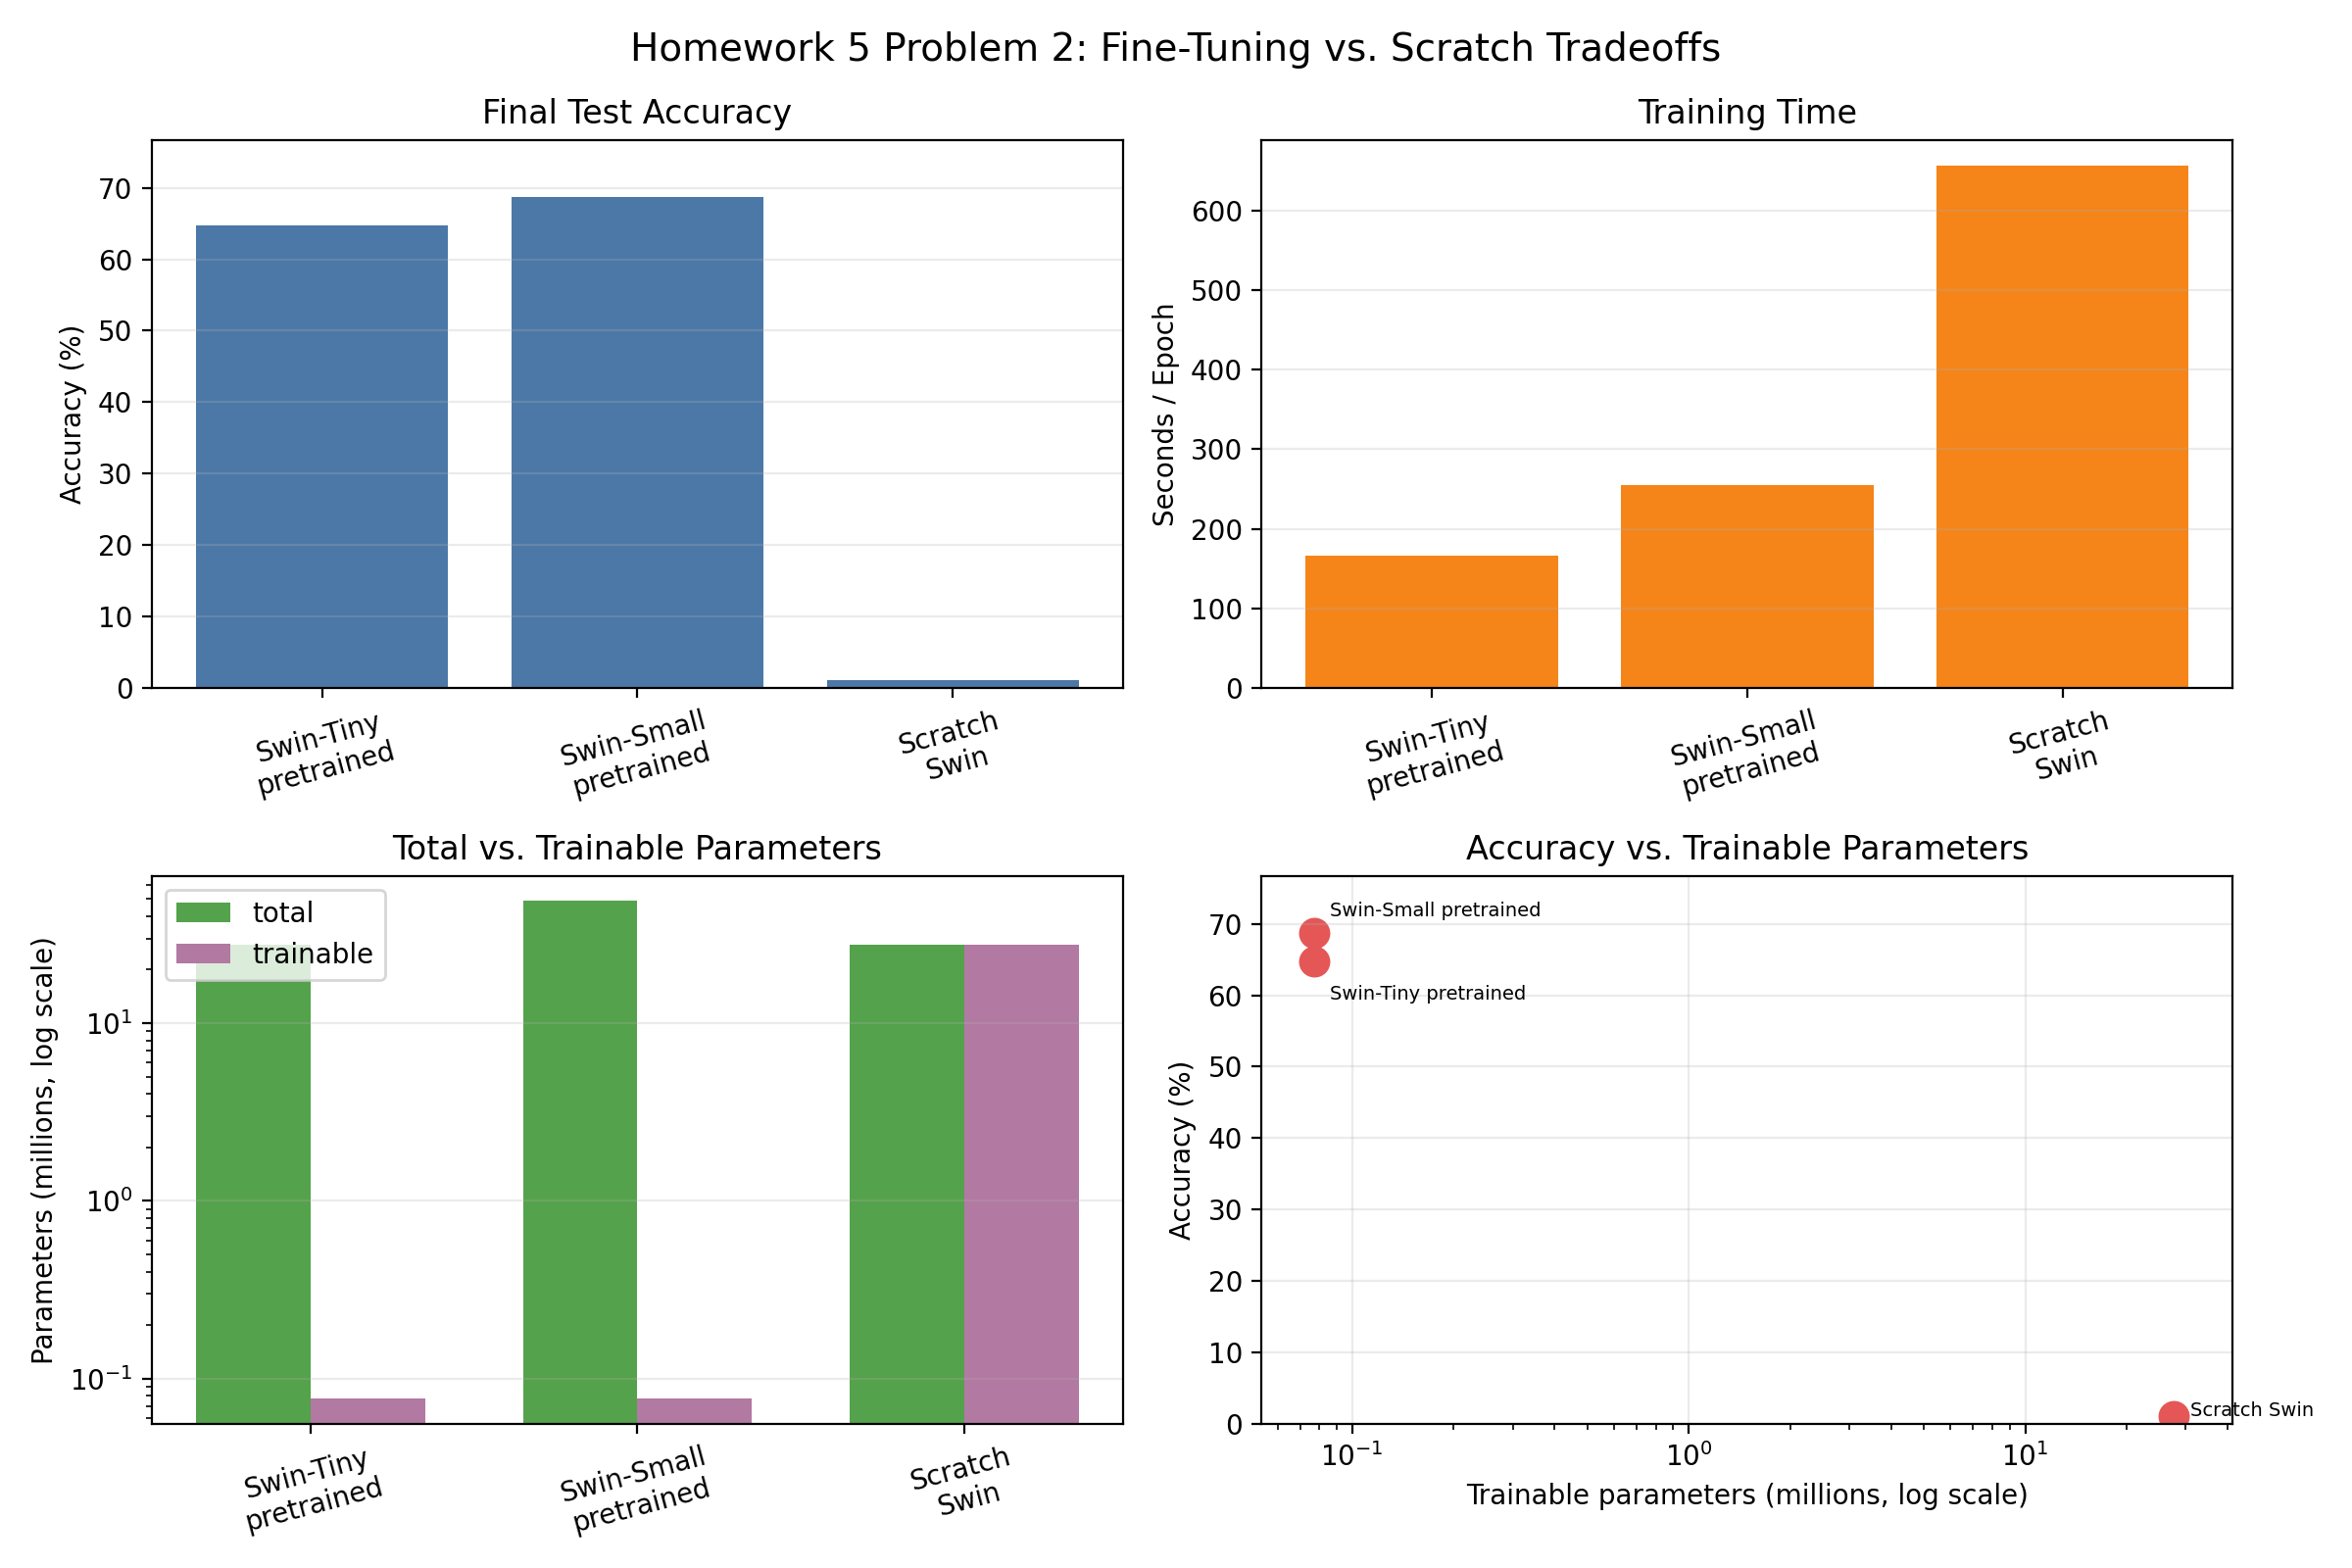

In [14]:
display(Markdown('### Loss and Accuracy Curves'))
display(Image(filename=str(plot_path)))
display(Markdown('### Accuracy, Runtime, and Fine-Tuning Tradeoffs'))
display(Image(filename=str(tradeoff_path)))

## Interpretation

The completed pretrained rows show strong transfer-learning performance after five epochs. Swin-Tiny reaches 64.78% accuracy and Swin-Small reaches 68.74% accuracy. Swin-Small has the better validation loss and test accuracy in the current artifacts, but it also has a larger total parameter count and higher time per epoch.

Scratch Swin stays near chance accuracy, reaching 1.00% accuracy after five CUDA epochs using 224 by 224 inputs. Its loss remains near ln(100), or about 4.605, which is what we expect for chance-level prediction over 100 classes. The plotted curves verify the training behavior: pretrained Swin losses fall and validation accuracy climbs, while scratch Swin stays flat. That is much lower than the pretrained Swin rows, which supports the transfer-learning advantage under a short schedule.